<a href="https://colab.research.google.com/github/desmckenzie/Capstone1/blob/main/Capstone1_Destiny_McKenzie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Getting into Business:
## Real Estate Investment Data Exploration

With data provided by the federal goverment, the possibilty of real estate investments is being considered. To develop a better understandin on housing-market trends, geographi differences, and potential investment opportunities, the dataset provided will be explored and analyzed.



In [ ]:
# import the dataset
!wget https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv

--2026-09-18 17:52:52--  https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv
Resolving www.fhfa.gov (www.fhfa.gov)... 54.92.167.213
Connecting to www.fhfa.gov (www.fhfa.gov)|54.92.167.213|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17154972 (16M) [text/csv]
Saving to: ‘hpi_master.csv.1’

hpi_master.csv.1    100%[===================>]  16.36M  --.-KB/s    in 0.08s   

2026-09-18 17:52:52 (207 MB/s) - ‘hpi_master.csv.1’ saved [17154972/17154972]



## 1. Understanding the Data

The FHFA dataset measures changes in single family homes across the US. Data is collected by state, nationally, and by metro area dating back to the late 1970s.

When understanding the data, the analysis needs to answer when the data was collected, where the data was collected, how it was acquired, and what attributes does the dataset contain.

- When was the acquired?
The data ranges from the late 1970s to 2026 (now), and is broken down into yearly, monthly, and quaterly.

- Where was the data acquired?
There is differing geographical locations within the data such as the United States but is further broken down into states by city, general states, and census divsions. There is also some data from Puerto Rico.

- How was the data acquired?
FHFA HPI is built from repeat mortgage transactions (sales and refinances) on single family homes whose mortgages were purchased or securitized. Each time one of the homes sells or is refinanced, the transaction enters the FIFHA database.

- What are the attributes of this dataset? What type of data do these attirbutes contain?:

In [ ]:
# confirm the file downloaded
!ls

# read the csv into a data frame
import pandas as pd
df = pd.read_csv("hpi_master.csv")

# look at the columns
df.columns

hpi_master.csv	hpi_master.csv.1  sample_data


/tmp/ipykernel_588/2104091946.py:6: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("hpi_master.csv")


Index(['hpi_type', 'hpi_flavor', 'frequency', 'level', 'place_name',
       'place_id', 'yr', 'period', 'index_nsa', 'index_sa', 'rstderr', 'note'],
      dtype='object')

The attributes come from the columns within the dataset. Based on the dataset these are the columns in the table:
- hpi_type = nominal
- hpi_flavor = nominal
- frequency = nominal
- level = nominal
- place_name = nominal
- place_id = nominal
- yr = interval
- period = interval
- index_nsa = ratio
- index_sa = ratio
- rstderr
- note

## 2. Data Summary & Initial Insights

Summary of the data contains the statitics for the attributes within the dataset, the empty or missing values, discusses potential strategies to handle them, and uses visualizations to communicate findings.

- Summary Statistics for the attributes (mean, median, mode, range, and standard deviation)


In [ ]:
# full descriptive summary of the mean, standard deviation, min and max(range) and quartiles
df.describe()


,yr,period,index_nsa,index_sa,rstderr
count,186011.000000,186011.000000,186011.000000,96114.000000,58220.000000
mean,2006.159926,2.581014,199.962128,216.670407,2.673249
std,12.004355,1.358702,116.125443,113.512712,2.222155
min,1975.000000,1.000000,18.600000,72.780000,0.000000
25%,1997.000000,2.000000,119.610000,137.290000,1.060000
50%,2007.000000,3.000000,172.130000,187.210000,2.050000
75%,2016.000000,4.000000,241.380000,258.337500,3.600000
max,2026.000000,12.000000,1326.940000,1043.200000,15.750000


In [ ]:
# get the median
df.median(numeric_only= True)

,0
yr,2007.00
period,3.00
index_nsa,172.13
index_sa,187.21
rstderr,2.05


In [ ]:
# get the mode
df.mode()

,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa,rstderr,note
0,traditional,all-transactions,quarterly,MSA,United States,USA,2001,2.0,100.0,100.0,0.0,\t
1,NaN,NaN,NaN,NaN,NaN,NaN,2002,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,2003,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,2004,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,2005,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,2006,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,2007,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,2008,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,2009,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,2010,NaN,NaN,NaN,NaN,NaN


Mode only returns a values when a number repeats. For each year, the numeric columns have unique values. If a column has no repeated values, Pandas will return NaN for that row. The year 2001 likely has at least one column where two or more values are identical so Pandas returns a mode.



It is important to identify the missing values within the dataset. The code below counts all the missing values in each column. There seems to be more missing values in columns: index_sa, rstderr, and note.




In [ ]:
# count all the missing values in each column
df.isnull().sum()

,0
hpi_type,0
hpi_flavor,0
frequency,0
level,0
place_name,0
place_id,0
yr,0
period,0
index_nsa,0
index_sa,89897


Investigating and exploring the summary statisitcs such as mean, median, standard deviation, and range is well represented with visualizations. Bar charts display the summary across all numeric columns. In order to gather information on the housing market trends, the focus will be on variables index_nsa and index_sa.

### Individual Plots for each Statistic:

**Mean**

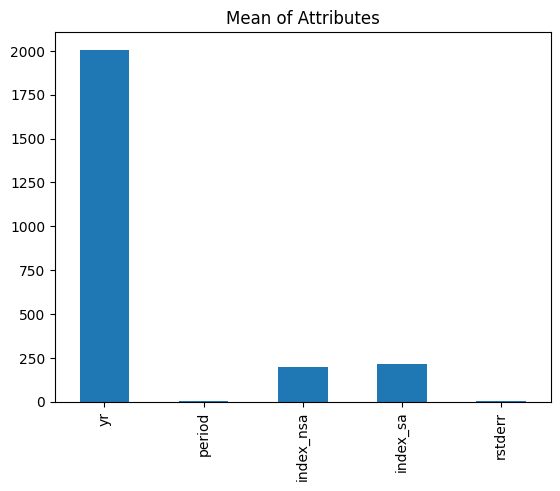

In [ ]:
# import library for plotting
import matplotlib.pyplot as plt

# plot the mean
df.mean(numeric_only = True).plot(kind = 'bar')
plt.title("Mean of Attributes")
plt.show()

For the FHFA housing index, the mean of index_nsa and index_sa reflects the typical home‑price index value across all regions and time periods. Because the mean is sensitive to extreme values, higher averages in the seasonally adjusted index suggest that seasonal smoothing elevates the overall level of the index. The mean of rstderr indicates the average uncertainty associated with the index estimates, helping assess the reliability of the underlying model. Overall, this visualization highlights the central tendency of the housing market and reveals which variables operate at higher or lower average levels.

**Median**

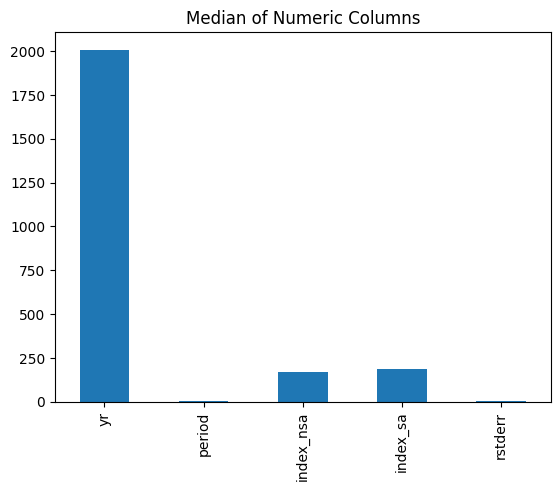

In [ ]:
# plot for the median
df.median(numeric_only=True).plot(kind='bar')
plt.title("Median of Numeric Columns")
plt.show()

The median bar chart shows the middle value of each numeric variable, providing a measure of central tendency that is robust to outliers. In housing data, where extreme price spikes or dips can occur, the median often gives a clearer picture of the “typical” index value. If the median is noticeably lower than the mean for index_nsa or index_sa, it suggests right‑skewness, meaning a subset of very high index values is pulling the mean upward.

**Standard Deviation**

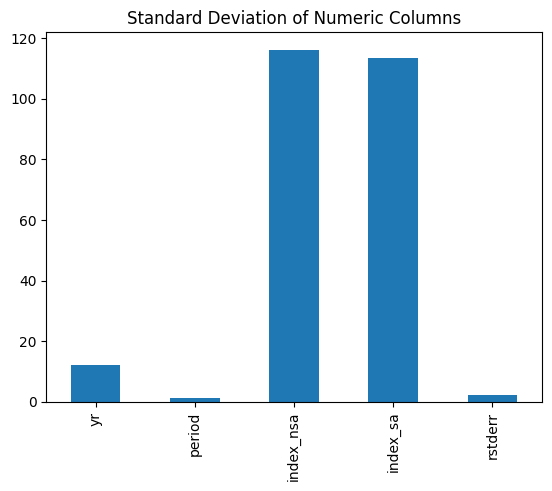

In [ ]:
# plot for the standard deviation
df.std(numeric_only=True).plot(kind='bar')
plt.title("Standard Deviation of Numeric Columns")
plt.show()

A high standard deviation in index_nsa or index_sa indicates that housing index values fluctuate widely across time and regions, reflecting diverse market conditions. Lower variability in rstderr suggests consistent model precision, while higher variability would indicate uneven reliability across observations.

**Range**

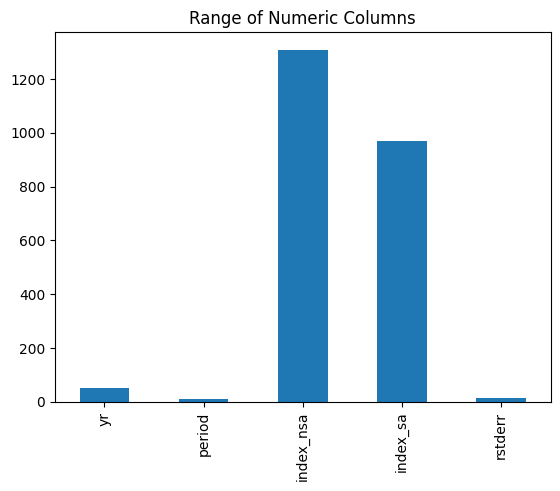

In [ ]:
# plot for the range
(df.max(numeric_only=True) - df.min(numeric_only=True)).plot(kind='bar')
plt.title("Range of Numeric Columns")
plt.show()


The range represents the difference between the minimum and maximum values within the dataset.

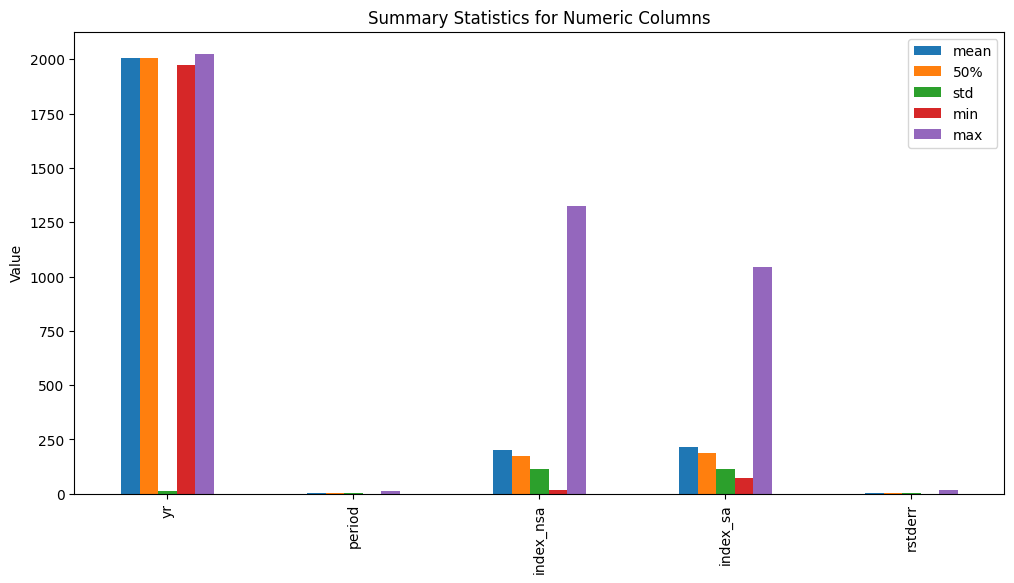

In [ ]:
# bar chart showing collective summary statistics
stats = df.describe().loc[['mean','50%','std','min','max']]
stats.T.plot(kind='bar', figsize=(12,6))
plt.title("Summary Statistics for Numeric Columns")
plt.ylabel("Value")
plt.show()


The mean represents the tendency of the housing index values. The bar chart shows the average values of each numeric variable, helping to compare tendencies across variables.

The mean(50th percentile) is the middle value when the data is sorted.

The Standard Deviation is the spread of data points. High standard deviation means that prices vary a lot. If the standard deviation is low than the housing prices are pretty stable.

The range is similar to the standard deviation, but it calculates the total spread of the data. It answers the question how far apart are the lowest and highest index values.

## 3. Expanding Your Investment Knowledge

Beyond the dataset provided by the FHFA, there are other data sources that could help inform investment strategies.

* **Why would this dataset be useful**

While FHFA tracks the using repeat-sales of homes with conforming mortgages, Zillow Home Value Index tracks using estimates for all homes sold or unsold. ZHVI covers a broader spectrum.

* **How could it complement the data you are currently analyzing**

ZHVI is constructed from Zillow's neutral Zestimate that covers over 100 million homes. ZHVI also tracks long-term appreciation like FHFA, represents the middle of the distribution to help confirm skewness patterns seen in FHFA, shows strong regional variation, is adjusted seasonally simjlar to FHFA's SA index, and has stable model estimnates.


* **Link to dataset - first section titled Home Values**
https://www.zillow.com/research/data/$0

## 4. Conclusion and Findings

Based on the dataset there are current trends within the housing market based that can influence investments.

FHFA Housing Price Index contains data that is mostly centered around 2006, so transactions in the early to mid 2000s were largely recorded. Median index values are lower than mean values, indicating right-skewness driven by periods of rapid price increase. The large standard deviation suggests that there is variation across regions and time consistent with the long historical span of the dataset. Overall, the housing market shows clear upward tracjectory, but the model remains stable as the indicator, rstderr, is relatively low meaning there are low standard errors.